<a href="https://colab.research.google.com/github/vadhri/cfd-notebook/blob/main/differencing_schemes/upwind.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Upwind differencing scheme

The transport equations derived as part of the notebook [1d_convection_diffusion.ipynb](https://github.com/vadhri/cfd-notebook/blob/main/1d_convection_diffusion.ipynb)

For a general node P, the equation is as below.

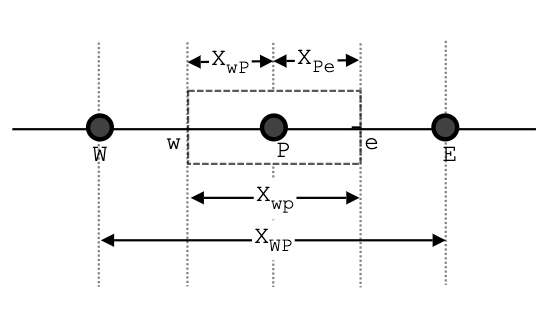

Replace the following for ease of notation.

$$ F = (\rho u) ; D = \frac{\Gamma}{\delta x} $$

$$ F_e \phi_e - F_w \phi_w = D_e ( \phi_E - \phi_P ) - D_w ( \phi_P - \phi_W ) $$

For upwind differencing scheme, $\phi_w = \phi_W, \phi_e = \phi_P$

$$ F_e \phi_P - F_w \phi_W = D_e ( \phi_E - \phi_P ) - D_w ( \phi_P - \phi_W ) $$

$$ (F_e + D_w + D_e) \phi_P = D_e \phi_E + (D_w + F_w) \phi_W $$

$$ ((D_w + F_w ) + (F_e - F_w) + D_e) \phi_P = D_e \phi_E + (D_w + F_w) \phi_W $$

$$ aE = D_e, aW = D_w + F_w, ap = aE + aW + (F_e-F_w) $$  


For boundary case of node 1,

$D_w = \frac{\Gamma}{\delta x / 2} = \frac{2 \Gamma}{\delta x} = 2D$

$\phi_W = \phi_A$

$$ ((2D + F ) + (F_e - F_w) + D) \phi_P = D \phi_E + (2D + F) \phi_A $$

For boundary case of node 5,

$D_e = \frac{\Gamma}{\delta x / 2} = \frac{2 \Gamma}{\delta x} = 2D$

$\phi_E = \phi_B$

$$ ((D + F) + (F_e - F_w) + 2D) \phi_P = 2D \phi_B + (D + F) \phi_W $$

$$ \boxed{a_P \phi_P = a_E \phi_E + a_W \phi_W + S_u }$$

$$ \boxed{a_P = a_W + a_E + (F_e - F_w ) - S_P}$$

|Node|aE|aW|$S_u$|$S_P$|
|-|-|-|-|-|
|1|D|0|(2D+F) $\phi_A$|-(2D+F)|
|2,3,4|D|D+F|0|0|
|5|0|D+F|2D$\phi_B$|-2D|

In [8]:
import numpy as np

def numerical_solution_upwind(F, D, phi_A, phi_B, num_nodes):
  # 1. Initialize a num_nodes x num_nodes NumPy array A and a num_nodes x 1 NumPy array B with zeros.
  A = np.zeros((num_nodes, num_nodes))
  B = np.zeros(num_nodes)

  # 2. Define the coefficients for the upwind scheme based on the provided text
  # For internal nodes (corresponds to Nodes 2,3,4 in the 5-node example)
  aP_internal = 2 * D + F
  aE_internal = D
  aW_internal = D + F

  # For boundary nodes (Node 1 and Node 5)
  aP_boundary = 3 * D + F

  # 3. Apply the left boundary condition for the first node (row 0, Node 1)
  # Equation for Node 1: (3D+F)phi_0 - D phi_1 = (2D+F)phi_A
  A[0, 0] = aP_boundary  # Coefficient for phi_0
  A[0, 1] = -aE_internal # Coefficient for phi_1
  B[0] = (2 * D + F) * phi_A # Source term S_u for Node 1

  # 4. Loop through the internal nodes (i from 1 to num_nodes - 2, corresponding to Nodes 2,3,4)
  # Equation for internal node i: -(D+F) phi_{i-1} + (2D+F) phi_i - D phi_{i+1} = 0
  for i in range(1, num_nodes - 1):
      A[i, i-1] = -aW_internal # Coefficient for phi_{i-1}
      A[i, i] = aP_internal    # Coefficient for phi_i
      A[i, i+1] = -aE_internal # Coefficient for phi_{i+1}
      B[i] = 0 # Source term S_u for internal nodes is 0

  # 5. Apply the right boundary condition for the last node (row num_nodes-1, Node 5)
  # Equation for Node 5: -(D+F) phi_{num_nodes-2} + (3D+F) phi_{num_nodes-1} = 2D phi_B
  A[num_nodes-1, num_nodes-2] = -aW_internal # Coefficient for phi_{num_nodes-2}
  A[num_nodes-1, num_nodes-1] = aP_boundary  # Coefficient for phi_{num_nodes-1}
  B[num_nodes-1] = 2 * D * phi_B # Source term S_u for Node 5

  # 6. Print the constructed A matrix and B vector (optional, for debugging).
  print("Constructed A matrix (Upwind):")
  print(A)
  print("\nConstructed B vector (Upwind):")
  print(B)

  # Solve the linear system A * phi = B
  phi = np.linalg.solve(A, B)

  return phi


In [52]:
# Let's assume some values for F, D, boundary conditions, and number of nodes
rho = 1.0 # density
u_velocity = 0.1 # velocity
Gamma = 0.1 # diffusion coefficient
dx = 0.2 # grid spacing
L = 1
# Calculate F and D
F_val = rho * u_velocity
D_val = Gamma / dx

phi_A_val = 1.0 # Left boundary condition
phi_B_val = 0.0 # Right boundary condition
num_nodes = 5 # Number of internal nodes

print(f"\n--- Upwind Differencing Solution ---")
print(f"F = {F_val}, D = {D_val}")
print(f"phi_A (Left BC) = {phi_A_val}, phi_B (Right BC) = {phi_B_val}")
solution_upwind = numerical_solution_upwind(F_val, D_val, phi_A_val, phi_B_val, num_nodes)
print("\nSolution (phi values for each node):")
print(solution_upwind)


--- Upwind Differencing Solution ---
F = 0.1, D = 0.5
phi_A (Left BC) = 1.0, phi_B (Right BC) = 0.0
Constructed A matrix (Upwind):
[[ 1.6 -0.5  0.   0.   0. ]
 [-0.6  1.1 -0.5  0.   0. ]
 [ 0.  -0.6  1.1 -0.5  0. ]
 [ 0.   0.  -0.6  1.1 -0.5]
 [ 0.   0.   0.  -0.6  1.6]]

Constructed B vector (Upwind):
[1.1 0.  0.  0.  0. ]

Solution (phi values for each node):
[0.93373341 0.7879469  0.6130031  0.40307053 0.15115145]


In [53]:

"""
Calculates the analytical solution for the 1-D steady-state convection-diffusion equation.

Args:
    x (float or np.array): Position(s) at which to calculate phi.
    u_val (float): Velocity.
    L_val (float): Length of the domain.
    rho_val (float): Density.
    Gamma_val (float): Diffusion coefficient.

Returns:
    float or np.array: The analytical solution for phi at position x.
"""
def phi_analytical(x, u_val, L_val, rho_val, Gamma_val):
    Pe = (rho_val * u_val * L_val) / Gamma_val
    phi_x = (np.exp(Pe * x / L_val) - np.exp(Pe)) / (1 - np.exp(Pe))
    return phi_x


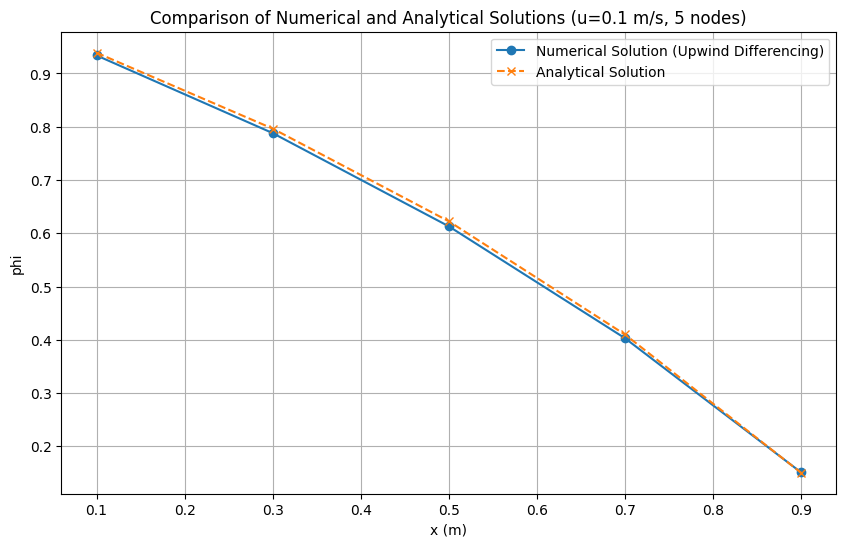

In [54]:
import matplotlib.pyplot as plt

# Calculate the effective grid spacing for plotting purposes
dx_effective = L / num_nodes

# Generate x-coordinates for the numerical solution (nodes) as cell centers
x_numerical = np.linspace(dx_effective / 2, L - dx_effective / 2, num_nodes)

# Calculate analytical solution at the numerical node positions
phi_analytical_values = phi_analytical(x_numerical, u_velocity, L, rho, Gamma)

# Plotting
plt.figure(figsize=(10, 6))
plt.plot(x_numerical, solution_upwind, 'o-', label='Numerical Solution (Upwind Differencing)')
plt.plot(x_numerical, phi_analytical_values, 'x--', label='Analytical Solution')

plt.xlabel('x (m)')
plt.ylabel('phi')
plt.title(f'Comparison of Numerical and Analytical Solutions (u={u_velocity} m/s, {num_nodes} nodes)')
plt.grid(True)
plt.legend()
plt.show()

In [55]:
import pandas as pd

# Create a DataFrame to display the values in a table
comparison_df = pd.DataFrame({
    'x_values': x_numerical,
    'Numerical Solution (Upwind)': solution_upwind,
    'Analytical Solution': phi_analytical_values
})

# Calculate the percentage error
comparison_df['% Error'] = ((comparison_df['Numerical Solution (Upwind)'] - comparison_df['Analytical Solution']) / comparison_df['Analytical Solution']) * 100

print("Comparison of x, Numerical, and Analytical values:")
display(comparison_df)

Comparison of x, Numerical, and Analytical values:


,x_values,Numerical Solution (Upwind),Analytical Solution,% Error
0,0.1,0.933733,0.938793,-0.538944
1,0.3,0.787947,0.796390,-1.060211
2,0.5,0.613003,0.622459,-1.519173
3,0.7,0.403071,0.410020,-1.694799
4,0.9,0.151151,0.150545,0.402843


### U = 2.5 m/s

In [58]:
# Let's assume some values for F, D, boundary conditions, and number of nodes
rho = 1.0 # density
u_velocity = 2.5 # velocity
Gamma = 0.1 # diffusion coefficient
dx = 0.2 # grid spacing
L = 1
# Calculate F and D
F_val = rho * u_velocity
D_val = Gamma / dx

phi_A_val = 1.0 # Left boundary condition
phi_B_val = 0.0 # Right boundary condition
num_nodes = 5 # Number of internal nodes

print(f"\n--- Upwind Differencing Solution ---")
print(f"F = {F_val}, D = {D_val}")
print(f"phi_A (Left BC) = {phi_A_val}, phi_B (Right BC) = {phi_B_val}")
solution_upwind = numerical_solution_upwind(F_val, D_val, phi_A_val, phi_B_val, num_nodes)
print("\nSolution (phi values for each node):")
print(solution_upwind)


--- Upwind Differencing Solution ---
F = 2.5, D = 0.5
phi_A (Left BC) = 1.0, phi_B (Right BC) = 0.0
Constructed A matrix (Upwind):
[[ 4.  -0.5  0.   0.   0. ]
 [-3.   3.5 -0.5  0.   0. ]
 [ 0.  -3.   3.5 -0.5  0. ]
 [ 0.   0.  -3.   3.5 -0.5]
 [ 0.   0.   0.  -3.   4. ]]

Constructed B vector (Upwind):
[3.5 0.  0.  0.  0. ]

Solution (phi values for each node):
[0.99984252 0.99874016 0.99212598 0.95244094 0.71433071]


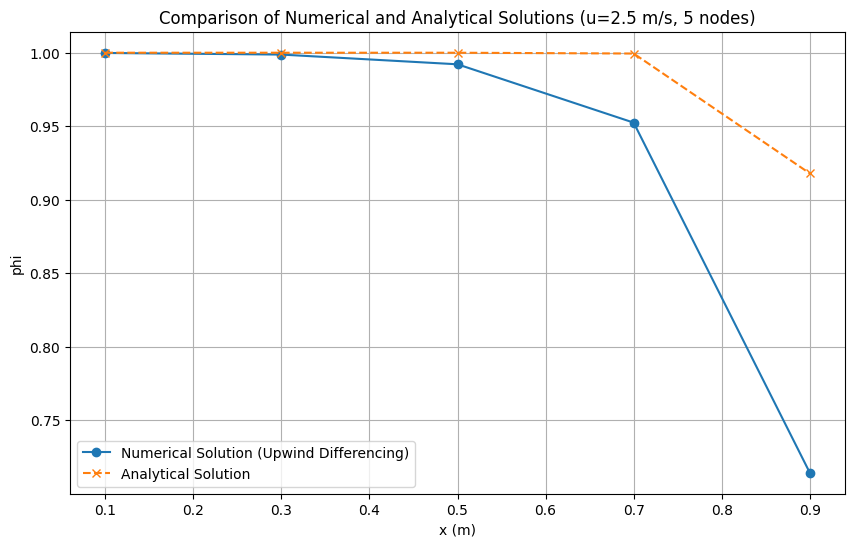

In [59]:
import matplotlib.pyplot as plt

# Calculate the effective grid spacing for plotting purposes
dx_effective = L / num_nodes

# Generate x-coordinates for the numerical solution (nodes) as cell centers
x_numerical = np.linspace(dx_effective / 2, L - dx_effective / 2, num_nodes)

# Calculate analytical solution at the numerical node positions
phi_analytical_values = phi_analytical(x_numerical, u_velocity, L, rho, Gamma)

# Plotting
plt.figure(figsize=(10, 6))
plt.plot(x_numerical, solution_upwind, 'o-', label='Numerical Solution (Upwind Differencing)')
plt.plot(x_numerical, phi_analytical_values, 'x--', label='Analytical Solution')

plt.xlabel('x (m)')
plt.ylabel('phi')
plt.title(f'Comparison of Numerical and Analytical Solutions (u={u_velocity} m/s, {num_nodes} nodes)')
plt.grid(True)
plt.legend()
plt.show()

In [60]:
# Create a DataFrame to display the values in a table
comparison_df = pd.DataFrame({
    'x_values': x_numerical,
    'Numerical Solution (Upwind)': solution_upwind,
    'Analytical Solution': phi_analytical_values
})

# Calculate the percentage error
comparison_df['% Error'] = ((comparison_df['Numerical Solution (Upwind)'] - comparison_df['Analytical Solution']) / comparison_df['Analytical Solution']) * 100

print("Comparison of x, Numerical, and Analytical values:")
display(comparison_df)

Comparison of x, Numerical, and Analytical values:


,x_values,Numerical Solution (Upwind),Analytical Solution,% Error
0,0.1,0.999843,1.000000,-0.015748
1,0.3,0.998740,1.000000,-0.125982
2,0.5,0.992126,0.999996,-0.787032
3,0.7,0.952441,0.999447,-4.703198
4,0.9,0.714331,0.917915,-22.178992
